<a href="https://colab.research.google.com/github/peulearning/notebooks_tcc/blob/main/ReSize_Stress_4Class_MobileNetV2_Fine_Tunning.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Modelo / Sistema de Classificação de Feridas - MobileNetV2

### Bacharelado em Sistemas de Informações

#### IFNMG Campus Januária

---

### Orientador: Drº Mr. Prof. Felipe Augusto Oliveira Mota  
### Co-orientador(a) : Mr. Profª Suzana Vieira Mota
### Discente: Pedro Henrique Araújo Mattos Ribeiro  

---

## Estudo da Implementação do Modelo MobileNetV2
### Classificação de Imagens de Feridas e Lesões Cutâneas

# Classificação de Feridas Cutâneas com MobileNetV2

Neste notebook, iremos aplicar o modelo **MobileNetV2**, uma rede neural convolucional leve desenvolvida pelo **Google**, para a **classificação de feridas cutâneas**.  

O objetivo é:
- Observar o desempenho comparado à rede CNN anterior.

---

## O que é o MobileNetV2?

O **MobileNetV2** é uma arquitetura eficiente para **visão computacional em dispositivos móveis e embarcados**.  
Sua estrutura se baseia em dois conceitos principais:

- **Convoluções separáveis em profundidade (Depthwise Separable Convolutions)**: aplicam um filtro por canal, reduzindo drasticamente o número de parâmetros.
- **Blocos Inverted Residual com Linear Bottlenecks**: permitem que a rede aprenda representações compactas, mantendo alta precisão.

A vantagem do MobileNetV2 é seu **baixo custo computacional** e **boa acurácia**, ideal para aplicações em **IoT médica** e **educação em enfermagem**.

---

## Estrutura geral do notebook

1. Importação das bibliotecas;
2. Preparação dos datasets (treino, validação e teste);
3. Configuração dos `ImageDataGenerator`;
4. Carregamento do MobileNetV2 pré-treinado;
5. Criação da nova cabeça de classificação;
6. Treinamento e Fine-tuning;
7. Avaliação e visualização dos resultados.


# - 1. Importações Iniciais

In [293]:
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras import layers, models
import matplotlib.pyplot as plt
import numpy as np
import os

print("TensorFlow versão:", tf.__version__)


TensorFlow versão: 2.20.0


In [294]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


# - 2. Célula para limpar Imagens do Drive

In [295]:
import os
import shutil


#Esta célula foi criada com intuito de apagar todas as imagens e diretórios para executar o modelo quantas vezes serem necessárias
# Lista de pastas a serem removidas
pastas_para_remover = [
    "/content/drive/MyDrive/data_wounds",
    "/content/drive/MyDrive/data_big",
    "/content/drive/MyDrive/images_ready",
    "/content/drive/MyDrive/data_split",
    "/content/drive/MyDrive/data_split_reduzido"
]

print("Iniciando a remoção das pastas...")

for pasta in pastas_para_remover:
    if os.path.exists(pasta):
        try:
            shutil.rmtree(pasta)
            print(f"Pasta '{pasta}' removida com sucesso.")
        except OSError as e:
            print(f"Erro ao remover a pasta '{pasta}': {e}")
    else:
        print(f"Pasta '{pasta}' não encontrada.")

print("✅ Limpeza concluída.")

Iniciando a remoção das pastas...
Pasta '/content/drive/MyDrive/data_wounds' não encontrada.
Pasta '/content/drive/MyDrive/data_big' não encontrada.
Pasta '/content/drive/MyDrive/images_ready' não encontrada.
Pasta '/content/drive/MyDrive/data_split' não encontrada.
Pasta '/content/drive/MyDrive/data_split_reduzido' não encontrada.
✅ Limpeza concluída.


# - 3. Descompacter o DataSet do artigo ou repositório   https://github.com/uwm-bigdata/wound-classification-using-images-and-locations/tree/main

In [296]:
# Descompactar
import zipfile
import os

# Caminho do arquivo ZIP
caminho_zip = "/content/drive/MyDrive/wound-classification-using-images-and-locations-main.zip"

# Caminho de destino para descompactar
destino = "/content/drive/MyDrive/extraido"

# Cria a pasta de destino se não existir
os.makedirs(destino, exist_ok=True)

# Descompacta o ZIP
with zipfile.ZipFile(caminho_zip, 'r') as zip_ref:
    zip_ref.extractall(destino)

print(f"Arquivos extraídos para: {destino}")

Arquivos extraídos para: /content/drive/MyDrive/extraido


In [297]:
import os

base_path = "/content/drive/MyDrive/extraido/wound-classification-using-images-and-locations-main/dataset"

for root, dirs, files in os.walk(base_path):
    imgs = [f for f in files if f.lower().endswith(('.jpg','.jpeg','.png'))]

    if len(imgs) > 0:
        print(f"{root}")
        print(f"Total imagens: {len(imgs)}")
        print("-"*50)

/content/drive/MyDrive/extraido/wound-classification-using-images-and-locations-main/dataset/Test/Test/BG
Total imagens: 25
--------------------------------------------------
/content/drive/MyDrive/extraido/wound-classification-using-images-and-locations-main/dataset/Test/Test/D
Total imagens: 46
--------------------------------------------------
/content/drive/MyDrive/extraido/wound-classification-using-images-and-locations-main/dataset/Test/Test/N
Total imagens: 25
--------------------------------------------------
/content/drive/MyDrive/extraido/wound-classification-using-images-and-locations-main/dataset/Test/Test/P
Total imagens: 34
--------------------------------------------------
/content/drive/MyDrive/extraido/wound-classification-using-images-and-locations-main/dataset/Test/Test/S
Total imagens: 42
--------------------------------------------------
/content/drive/MyDrive/extraido/wound-classification-using-images-and-locations-main/dataset/Test/Test/V
Total imagens: 62
------

# - 4. Listagem de Pasta do Zip

In [298]:
# Listar somente pastas da estrutura extraída
for root, dirs, files in os.walk(destino):
    level = root.replace(destino, '').count(os.sep)
    indent = ' ' * 4 * level
    print(f"{indent}{os.path.basename(root)}/")
    for d in dirs:
        sub_indent = ' ' * 4 * (level + 1)
        print(f"{sub_indent}{d}/")

extraido/
    wound-classification-using-images-and-locations-main/
    wound-classification-using-images-and-locations-main/
        dataset/
        dataset/
            Test/
            Train/
            Test/
                Test/
                __MACOSX/
                Test/
                    BG/
                    D/
                    N/
                    P/
                    S/
                    V/
                    BG/
                    D/
                    N/
                    P/
                    S/
                    V/
                __MACOSX/
                    Test/
                    Test/
                        BG/
                        D/
                        N/
                        P/
                        S/
                        V/
                        BG/
                        D/
                        N/
                        P/
                        S/
                        V/
            Train/
              

# - 5. Unindo todas as imagens para facilitar

In [299]:
import os
import shutil
from pathlib import Path

# ==========================
# DESTINO
# ==========================

dataset_master = "/content/drive/MyDrive/dataset_master"

if os.path.exists(dataset_master):
    shutil.rmtree(dataset_master)

os.makedirs(dataset_master)

# ==========================
# MAPEAMENTO
# ==========================

map_classes = {
    "D": "diabetic",
    "N": "normal",
    "P": "pressure",
    "S": "sirurgical",
    "V": "venous",
    "BG": "background"
}

# ==========================
# ORIGENS
# ==========================

train_dir = "/content/drive/MyDrive/extraido/wound-classification-using-images-and-locations-main/dataset/Train/Train"

test_dir = "/content/drive/MyDrive/extraido/wound-classification-using-images-and-locations-main/dataset/Test/Test"

# ==========================
# COPIAR TRAIN
# ==========================

for classe in os.listdir(train_dir):

    origem_classe = os.path.join(train_dir, classe)

    if not os.path.isdir(origem_classe):
        continue

    destino_classe = os.path.join(dataset_master, classe)

    os.makedirs(destino_classe, exist_ok=True)

    for arquivo in os.listdir(origem_classe):

        origem_img = os.path.join(origem_classe, arquivo)

        if os.path.isfile(origem_img):

            novo_nome = f"train_{arquivo}"

            shutil.copy2(
                origem_img,
                os.path.join(destino_classe, novo_nome)
            )

# ==========================
# COPIAR TEST
# ==========================

for sigla in os.listdir(test_dir):

    origem_classe = os.path.join(test_dir, sigla)

    if not os.path.isdir(origem_classe):
        continue

    classe = map_classes.get(sigla)

    if classe is None:
        continue

    destino_classe = os.path.join(dataset_master, classe)

    os.makedirs(destino_classe, exist_ok=True)

    for arquivo in os.listdir(origem_classe):

        origem_img = os.path.join(origem_classe, arquivo)

        if os.path.isfile(origem_img):

            novo_nome = f"test_{arquivo}"

            shutil.copy2(
                origem_img,
                os.path.join(destino_classe, novo_nome)
            )

print("Dataset mestre criado com sucesso!")
print(dataset_master)

Dataset mestre criado com sucesso!
/content/drive/MyDrive/dataset_master


In [300]:
# # Salvar imagen e m um data set organizado para trabalhar melhor /content/base_de_dados_feridas
# import os
# import shutil

# # Caminhos
# caminho_base = "/content/drive/MyDrive/data_wounds"
# os.makedirs(caminho_base, exist_ok=True)

# # Mapeamento das siglas para nomes completos
# sigla_para_nome = {
#     'D': 'diabetic',
#     'N': 'normal',
#     'P': 'pressure',
#     'S': 'sirurgical',
#     'V': 'venous',
#     'BG':'background'
# }

# # Caminhos das pastas de origem
# train_dir = "/content/drive/MyDrive/extraido/wound-classification-using-images-and-locations-main/dataset/Train/Train"
# test_dir = "/content/drive/MyDrive/extraido/wound-classification-using-images-and-locations-main/dataset/Test/Test"

# # Função para copiar as imagens
# def copiar_imagens(origem, destino_base, renomear_pasta=False):
#     for nome_pasta in os.listdir(origem):
#         caminho_origem = os.path.join(origem, nome_pasta)

#         if not os.path.isdir(caminho_origem):
#             continue

#         # Renomeia caso seja pasta de sigla
#         if renomear_pasta and nome_pasta in sigla_para_nome:
#             nome_final = sigla_para_nome[nome_pasta]
#         else:
#             nome_final = nome_pasta

#         caminho_destino = os.path.join(destino_base, nome_final)
#         os.makedirs(caminho_destino, exist_ok=True)

#         # Copia os arquivos de imagem
#         for nome_arquivo in os.listdir(caminho_origem):
#             origem_arquivo = os.path.join(caminho_origem, nome_arquivo)
#             destino_arquivo = os.path.join(caminho_destino, nome_arquivo)

#             if os.path.isfile(origem_arquivo):
#                 shutil.copy2(origem_arquivo, destino_arquivo)

# # Copiar imagens de Train (sem renomear)
# copiar_imagens(train_dir, caminho_base)

# # Copiar imagens de Test (renomeando siglas)
# copiar_imagens(test_dir, caminho_base, renomear_pasta=True)

# print("Imagens unificadas em:", caminho_base)

In [301]:
# import shutil
# import os

# # List of folders to remove from /content/drive/MyDrive/data_wounds
# folders_to_remove = [
#     "/content/drive/MyDrive/data_wounds/sirurgical",
#     "/content/drive/MyDrive/data_wounds/venous"
# ]

# print("Iniciando a remoção das pastas indesejadas...")

# for pasta in folders_to_remove:
#     if os.path.exists(pasta):
#         try:
#             shutil.rmtree(pasta)
#             print(f"Pasta '{os.path.basename(pasta)}' removida com sucesso.")
#         except OSError as e:
#             print(f"Erro ao remover a pasta '{os.path.basename(pasta)}': {e}")
#     else:
#         print(f"Pasta '{os.path.basename(pasta)}' não encontrada.")

# print("✅ Limpeza concluída.")

In [302]:
import shutil
import os

# List of folders to remove from /content/drive/MyDrive/data_wounds
folders_to_remove = [
    "/content/drive/MyDrive/dataset_master/sirurgical",
    "/content/drive/MyDrive/dataset_master/venous"
]

print("Iniciando a remoção das pastas indesejadas...")

for pasta in folders_to_remove:
    if os.path.exists(pasta):
        try:
            shutil.rmtree(pasta)
            print(f"Pasta '{os.path.basename(pasta)}' removida com sucesso.")
        except OSError as e:
            print(f"Erro ao remover a pasta '{os.path.basename(pasta)}': {e}")
    else:
        print(f"Pasta '{os.path.basename(pasta)}' não encontrada.")

print("✅ Limpeza concluída.")

Iniciando a remoção das pastas indesejadas...
Pasta 'sirurgical' removida com sucesso.
Pasta 'venous' removida com sucesso.
✅ Limpeza concluída.


# - 6. Quantidade de imagens por diretórios

In [303]:
import os

base = "/content/drive/MyDrive/dataset_master"

for classe in sorted(os.listdir(base)):

    caminho = os.path.join(base, classe)

    if os.path.isdir(caminho):

        qtd = len([
            f for f in os.listdir(caminho)
            if f.lower().endswith((".jpg",".jpeg",".png"))
        ])

        print(f"{classe}: {qtd}")

background: 25
diabetic: 185
normal: 100
pressure: 134


In [304]:
import os

base = "/content/drive/MyDrive/dataset_master"

for classe in sorted(os.listdir(base)):
    caminho = os.path.join(base, classe)

    if os.path.isdir(caminho):
        print(classe)

background
diabetic
normal
pressure


In [305]:
# # @title
# # contar imagem na pasta da base de dados
# import os

# # Caminho para a pasta base
# base_dir = "/content/drive/MyDrive/data_wounds"

# # Inicializar o contador total de imagens
# total_images = 0

# # Iterar pelas pastas dentro da pasta base
# for folder_name in os.listdir(base_dir):
#   folder_path = os.path.join(base_dir, folder_name)
#   if os.path.isdir(folder_path):  # Verificar se é uma pasta
#     image_count = 0
#     for filename in os.listdir(folder_path):
#       if filename.lower().endswith(('.png', '.jpg', '.jpeg', '.bmp', '.gif')): # Inclui mais extensões de imagem
#         image_count += 1
#     total_images += image_count
#     print(f"Pasta '{folder_name}': {image_count} imagens")

# print(f"Total de imagens no dataset: {total_images}")

# - 7. Balanceamento de Imagens

In [306]:
# import os
# import shutil
# #from keras.preprocessing.image import ImageDataGenerator, load_img, img_to_array, array_to_img
# import tensorflow as tf
# from keras.utils import load_img, img_to_array, array_to_img #updated imports
# import numpy as np
# from tqdm import tqdm
# from tensorflow.keras.preprocessing.image import ImageDataGenerator # Import the ImageDataGenerator class


# # Configurações
# CAMINHO_ORIGEM = '/content/drive/MyDrive/data_wounds'
# CAMINHO_DESTINO = '/content/drive/MyDrive/data_big'
# NUM_IMAGENS_DESEJADAS = 900  # Você pode mudar esse valor para 900, etc.
# TAMANHO_IMAGEM = (224, 224)  # Você também pode mudar aqui

# # Aumentos suaves (para manter características das feridas)
# datagen = ImageDataGenerator(
#     rotation_range=10,
#     width_shift_range=0.02,
#     height_shift_range=0.02,
#     zoom_range=0.05,
#     brightness_range=[0.9, 1.1],
#     horizontal_flip=True,
#     fill_mode='nearest'
# )

# # Criar pasta de destino do zero
# if os.path.exists(CAMINHO_DESTINO):
#     shutil.rmtree(CAMINHO_DESTINO)
# os.makedirs(CAMINHO_DESTINO, exist_ok=True)

# # Para cada classe
# for classe in os.listdir(CAMINHO_ORIGEM):
#     pasta_origem = os.path.join(CAMINHO_ORIGEM, classe)
#     pasta_destino = os.path.join(CAMINHO_DESTINO, classe)
#     os.makedirs(pasta_destino, exist_ok=True)

#     imagens_existentes = os.listdir(pasta_origem)
#     total_existente = len(imagens_existentes)

#     print(f"\nClasse '{classe}': {total_existente} imagens existentes.")

#     contador = 0
#     pbar = tqdm(total=NUM_IMAGENS_DESEJADAS, desc=f"Gerando para {classe}")

#     # Copiar imagens originais
#     for nome_img in imagens_existentes:
#         caminho_img = os.path.join(pasta_origem, nome_img)
#         shutil.copy(caminho_img, os.path.join(pasta_destino, nome_img))
#         contador += 1
#         pbar.update(1)
#         if contador >= NUM_IMAGENS_DESEJADAS:
#             break

#     # Se ainda não atingiu a quantidade desejada, gerar aumentadas
#     while contador < NUM_IMAGENS_DESEJADAS:
#         for nome_img in imagens_existentes:
#             img_path = os.path.join(pasta_origem, nome_img)
#             img = load_img(img_path, target_size=TAMANHO_IMAGEM)
#             x = img_to_array(img)
#             x = x.reshape((1,) + x.shape)

#             # Gerar apenas uma imagem aumentada por vez
#             for batch in datagen.flow(x, batch_size=1):
#                 img_aumentada = array_to_img(batch[0])
#                 nome_arquivo = f"aumentada_{contador}_{nome_img}"
#                 img_aumentada.save(os.path.join(pasta_destino, nome_arquivo))
#                 contador += 1
#                 pbar.update(1)
#                 break  # Apenas uma imagem por iteração
#             if contador >= NUM_IMAGENS_DESEJADAS:
#                 break
#     pbar.close()

# print("\n✅ Aumento de dados concluído com sucesso!")

# - 8. Contagem de Imagens depois do Balanceamento

In [307]:
# contar imagem na pasta da base de dados

import os

# Caminho para a pasta base
base_dir = "/content/drive/MyDrive/dataset_master"

# Inicializar o contador total de imagens
total_images = 0

# Iterar pelas pastas dentro da pasta base
for folder_name in os.listdir(base_dir):
  folder_path = os.path.join(base_dir, folder_name)
  if os.path.isdir(folder_path):  # Verificar se é uma pasta
    image_count = 0
    for filename in os.listdir(folder_path):
      if filename.lower().endswith(('.png', '.jpg', '.jpeg', '.bmp', '.gif')): # Inclui mais extensões de imagem
        image_count += 1
    total_images += image_count
    print(f"Pasta '{folder_name}': {image_count} imagens")

print(f"Total de imagens no dataset: {total_images}")

Pasta 'diabetic': 185 imagens
Pasta 'normal': 100 imagens
Pasta 'pressure': 134 imagens
Pasta 'background': 25 imagens
Total de imagens no dataset: 444


# - 9. Pasta de Saída para Resultados

In [308]:
import os
from PIL import Image
import shutil

# Caminho da base original
CAMINHO_ORIGINAL = "/content/drive/MyDrive/dataset_master"
# Caminho para salvar imagens processadas
CAMINHO_SAIDA = "/content/drive/MyDrive/dataset_master_output"
# Tamanho desejado
TAMANHO = (224, 224) # Tamanho Ideal // Padrão

# Cria a pasta de saída se não existir
os.makedirs(CAMINHO_SAIDA, exist_ok=True)

# Loop pelas classes (pastas)
for classe in os.listdir(CAMINHO_ORIGINAL):
    pasta_classe_origem = os.path.join(CAMINHO_ORIGINAL, classe)
    pasta_classe_saida = os.path.join(CAMINHO_SAIDA, classe)

    if not os.path.isdir(pasta_classe_origem):
        continue

    os.makedirs(pasta_classe_saida, exist_ok=True)

    # Loop pelas imagens da classe
    for nome_arquivo in os.listdir(pasta_classe_origem):
        caminho_imagem = os.path.join(pasta_classe_origem, nome_arquivo)

        try:
            img = Image.open(caminho_imagem)

            # Converter para RGB se não for
            if img.mode != 'RGB':
                img = img.convert('RGB')

            # Redimensionar
            img = img.resize(TAMANHO)

            # Salvar imagem processada
            caminho_saida = os.path.join(pasta_classe_saida, nome_arquivo)
            img.save(caminho_saida)

        except Exception as e:
            print(f"Erro ao processar {caminho_imagem}: {e}")

# - 10. Separando as Pastas Treinamento / Validação / Teste

In [309]:
import os
import shutil
from sklearn.model_selection import train_test_split

dataset_master = "/content/drive/MyDrive/dataset_master" # Verificar se devo estar pegando do output em vez do dataset original
dataset_split = "/content/drive/MyDrive/dataset_master_split"

# Remove split anterior
if os.path.exists(dataset_split):
    shutil.rmtree(dataset_split)

# Cria estrutura
for subset in ["train", "validation", "test"]:
    os.makedirs(os.path.join(dataset_split, subset), exist_ok=True)

# Processa cada classe separadamente
for classe in os.listdir(dataset_master):

    classe_path = os.path.join(dataset_master, classe)

    if not os.path.isdir(classe_path):
        continue

    imagens = [
        f for f in os.listdir(classe_path)
        if f.lower().endswith((".jpg", ".jpeg", ".png"))
    ]

    # 70% treino
    train_imgs, temp_imgs = train_test_split(
        imagens,
        test_size=0.30,
        random_state=42,
        shuffle=True
    )

    # 15% validação / 15% teste
    val_imgs, test_imgs = train_test_split(
        temp_imgs,
        test_size=0.50,
        random_state=42,
        shuffle=True
    )

    # cria pastas
    for subset in ["train", "validation", "test"]:
        os.makedirs(
            os.path.join(dataset_split, subset, classe),
            exist_ok=True
        )

    # copiar treino
    for img in train_imgs:
        shutil.copy2(
            os.path.join(classe_path, img),
            os.path.join(dataset_split, "train", classe, img)
        )

    # copiar validação
    for img in val_imgs:
        shutil.copy2(
            os.path.join(classe_path, img),
            os.path.join(dataset_split, "validation", classe, img)
        )

    # copiar teste
    for img in test_imgs:
        shutil.copy2(
            os.path.join(classe_path, "test", classe, img)
            if False else os.path.join(classe_path, img),
            os.path.join(dataset_split, "test", classe, img)
        )

print("Split criado com sucesso!")

Split criado com sucesso!


In [310]:
import os

base = "/content/drive/MyDrive/dataset_master_split"

for subset in ["train", "validation", "test"]:

    print(f"\n{subset.upper()}")

    total = 0

    for classe in sorted(os.listdir(os.path.join(base, subset))):

        caminho = os.path.join(base, subset, classe)

        qtd = len(os.listdir(caminho))

        total += qtd

        print(f"{classe}: {qtd}")

    print("TOTAL:", total)


TRAIN
background: 17
diabetic: 129
normal: 70
pressure: 93
TOTAL: 309

VALIDATION
background: 4
diabetic: 28
normal: 15
pressure: 20
TOTAL: 67

TEST
background: 4
diabetic: 28
normal: 15
pressure: 21
TOTAL: 68


In [311]:
# import os
# import shutil
# import random

# # Caminho do dataset original
# origem = "/content/drive/MyDrive/dataset_master_output"

# # Novo caminho para os dados divididos
# destino_base = "/content/drive/MyDrive/dataset_master_split"

# # Proporções
# train_split = 0.7
# val_split = 0.15
# test_split = 0.15

# # Garante que os diretórios existem
# os.makedirs(destino_base, exist_ok=True)
# for split in ['train', 'val', 'test']:
#     for classe in os.listdir(origem):
#         os.makedirs(os.path.join(destino_base, split, classe), exist_ok=True)

# # Loop pelas classes
# for classe in os.listdir(origem):
#     caminho_classe = os.path.join(origem, classe)
#     imagens = os.listdir(caminho_classe)
#     random.shuffle(imagens)

#     total = len(imagens)
#     n_train = int(train_split * total)
#     n_val = int(val_split * total)

#     train_imgs = imagens[:n_train]
#     val_imgs = imagens[n_train:n_train + n_val]
#     test_imgs = imagens[n_train + n_val:]

#     for nome_img in train_imgs:
#         shutil.copy(os.path.join(caminho_classe, nome_img), os.path.join(destino_base, 'train', classe))

#     for nome_img in val_imgs:
#         shutil.copy(os.path.join(caminho_classe, nome_img), os.path.join(destino_base, 'val', classe))

#     for nome_img in test_imgs:
#         shutil.copy(os.path.join(caminho_classe, nome_img), os.path.join(destino_base, 'test', classe))

# print("✅ Imagens separadas em treino, validação e teste!")

In [312]:
import os

for pasta in [
    "/content/drive/MyDrive/dataset_master_split/train",
    "/content/drive/MyDrive/dataset_master_split/validation",
    "/content/drive/MyDrive/dataset_master_split/test"
]:
    print(pasta, os.path.exists(pasta))

/content/drive/MyDrive/dataset_master_split/train True
/content/drive/MyDrive/dataset_master_split/validation True
/content/drive/MyDrive/dataset_master_split/test True


# - 11. Gerador de Dados de Imagem

In [313]:
import numpy as np

def print_class_distribution(generator, name):
    classes = generator.classes
    labels = list(generator.class_indices.keys())
    unique, counts = np.unique(classes, return_counts=True)
    print(f"\nDistribuição {name}:")
    for label, count in zip(labels, counts):
        print(f" - {label}: {count} ({count/sum(counts):.1%})")

print_class_distribution(train_generator, "Treino")
print_class_distribution(val_generator, "Validação")
print_class_distribution(test_generator, "Teste")


Distribuição Treino:
 - background: 17 (5.5%)
 - diabetic: 129 (41.7%)
 - normal: 70 (22.7%)
 - pressure: 93 (30.1%)

Distribuição Validação:
 - background: 4 (6.0%)
 - diabetic: 28 (41.8%)
 - normal: 15 (22.4%)
 - pressure: 20 (29.9%)

Distribuição Teste:
 - background: 4 (5.9%)
 - diabetic: 28 (41.2%)
 - normal: 15 (22.1%)
 - pressure: 21 (30.9%)


In [314]:
from sklearn.utils.class_weight import compute_class_weight
import numpy as np

# Pega as classes reais do gerador
classes = train_generator.classes

# Calcula os pesos balanceados
class_weights = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(classes),
    y=classes
)

# Converte para um dicionário (formato que o Keras exige)
class_weight_dict = dict(enumerate(class_weights))
print(f"Pesos das classes: {class_weight_dict}")

Pesos das classes: {0: np.float64(4.544117647058823), 1: np.float64(0.5988372093023255), 2: np.float64(1.1035714285714286), 3: np.float64(0.8306451612903226)}


In [315]:
# Gerador para treinamento (com augmentação)
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input # Import preprocess_input

train_datagen = ImageDataGenerator(
    preprocessing_function=preprocess_input,
    rotation_range=20,
    width_shift_range=0.1,
    height_shift_range=0.1,
    shear_range=0.1,
    zoom_range=0.1,
    horizontal_flip=True,
    fill_mode='nearest'
)

# Gerador para validação e teste (sem augmentação)
val_test_datagen = ImageDataGenerator(preprocessing_function=preprocess_input)

train_generator = train_datagen.flow_from_directory(
    "/content/drive/MyDrive/dataset_master_split/train",
    target_size=(320, 320), # aumentando resolução
    batch_size=16, # 32
    class_mode='categorical'
)

val_generator = val_test_datagen.flow_from_directory(
    "/content/drive/MyDrive/dataset_master_split/validation",
    target_size=(320, 320), # aumentando resolução
    batch_size=16, #32
    class_mode='categorical'
)

test_generator = val_test_datagen.flow_from_directory(
    "/content/drive/MyDrive/dataset_master_split/test",
    target_size=(320, 320),
    batch_size=16, # 32
    class_mode='categorical',
    shuffle=False
)

Found 309 images belonging to 4 classes.
Found 67 images belonging to 4 classes.
Found 68 images belonging to 4 classes.


# - 12. Rede Convolucional / MobileNetV2

In [316]:
# Carregar base pré-treinada
base_model = tf.keras.applications.MobileNetV2(
    input_shape=(320, 320, 3), # 224 , 224, 3
    include_top=False,
    weights='imagenet'
)
base_model.trainable = False  # Etapa 1: congelar a base

/tmp/ipykernel_44406/2419332283.py:2: UserWarning: `input_shape` is undefined or non-square, or `rows` is not in [96, 128, 160, 192, 224]. Weights for input shape (224, 224) will be loaded as the default.
  base_model = tf.keras.applications.MobileNetV2(


In [317]:
# inputs = tf.keras.Input(shape=(224, 224, 3))
# x = base_model(inputs, training=False)
# # x = layersTgo()(x)
# x = layers.Dropout(0.3)(x) #0.4
# x = layers.Dense(128, activation='relu')(x) #64
# x = layers.Dropout(0.3)(x)
# outputs = layers.Dense(train_generator.num_classes, activation='softmax')(x)

# model = models.Model(inputs, outputs)

inputs = tf.keras.Input(shape=(320,320,3) ) # 224,224

x = base_model(inputs, training=False)

x = layers.GlobalAveragePooling2D()(x)

x = layers.Dropout(0.3)(x)

x = layers.Dense(128, activation='relu')(x)

x = layers.Dropout(0.3)(x)

outputs = layers.Dense(
    train_generator.num_classes,
    activation='softmax'
)(x)

model = tf.keras.Model(inputs, outputs)

In [318]:
# Compilar com LR menor
from tensorflow.keras.optimizers import Adam

model.compile(
    optimizer=Adam(learning_rate=1e-3), # Antes era 5 1e-5 0.001  / 0.00001
    loss='categorical_crossentropy',
    metrics=['accuracy'] #recall
)

In [319]:
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.callbacks import LearningRateScheduler

# 1. Define a função do Warm-up
def warmup_scheduler(epoch, lr):
    if epoch < 3:
        return 1e-6  # Warm-up
    elif epoch == 3:
        return 1e-5  # Sobe para o LR alvo
    else:
        return lr    # Retorna o LR atual, permitindo que o ReduceLROnPlateau o modifique se necessário


callbacks = [
    # EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True),
    # ReduceLROnPlateau(monitor='val_loss', factor=0.3, patience=3, min_lr=1e-6)
    EarlyStopping(
        monitor='val_loss',
        patience=10,             # Espera 10 épocas para dar margem ao Plateau
        restore_best_weights=True # Garante que vai salvar o modelo da época 21 (o melhor)
    ),

    ReduceLROnPlateau(
        monitor='val_loss',
        patience=4,              # Age antes do EarlyStopping
        factor=0.2,              # Reduz o LR em 5 vezes
        verbose=1
    )
]


# 2. Cria os callbacks da Fase 2
fine_callbacks = [
    EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True),
    ReduceLROnPlateau(monitor='val_loss', patience=4, factor=0.2, verbose=1),
    LearningRateScheduler(warmup_scheduler, verbose=1) # A mágica acontece aqui
]

# ===== Fase 1: Treinar só a cabeça =====
print("\n🔹 Fase 1: Treinando apenas as camadas densas...")
history = model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=15, #  / Recursos Computacional  / Teto Computacional  / Limite de Recurso
    callbacks=callbacks,
    class_weight=class_weight_dict
)

# ===== Fase 2: Fine-tuning =====
print("\n🔹 Fase 2: Liberando parte das camadas da base...")

# base_model.trainable = True
# for layer in base_model.layers[:-15]:  # congela tudo, exceto as 30 últimas / 150 camadas
#     layer.trainable = False

base_model.trainable = True

# 1. Congela todas as camadas primeiro
for layer in base_model.layers:
    layer.trainable = False

# 2. Descongela apenas as camadas que NÃO são BatchNormalization
for layer in base_model.layers[-60:]:
    if not isinstance(layer, tf.keras.layers.BatchNormalization):
        layer.trainable = True
    else:
        layer.trainable = False # Força o BN a continuar em modo de inferência

model.compile(
    optimizer=Adam(learning_rate=1e-5), #Deixa 5 mais baixo e seguro
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

fine_history = model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=25,
    callbacks=fine_callbacks
)



🔹 Fase 1: Treinando apenas as camadas densas...
Epoch 1/15
20/20 ━━━━━━━━━━━━━━━━━━━━ 54s 2s/step - accuracy: 0.5113 - loss: 1.2010 - val_accuracy: 0.7910 - val_loss: 0.6096 - learning_rate: 0.0010
Epoch 2/15
20/20 ━━━━━━━━━━━━━━━━━━━━ 80s 2s/step - accuracy: 0.7411 - loss: 0.5156 - val_accuracy: 0.7910 - val_loss: 0.5717 - learning_rate: 0.0010
Epoch 3/15
20/20 ━━━━━━━━━━━━━━━━━━━━ 45s 2s/step - accuracy: 0.7799 - loss: 0.4256 - val_accuracy: 0.8507 - val_loss: 0.4146 - learning_rate: 0.0010
Epoch 4/15
20/20 ━━━━━━━━━━━━━━━━━━━━ 45s 2s/step - accuracy: 0.8058 - loss: 0.3719 - val_accuracy: 0.7910 - val_loss: 0.4970 - learning_rate: 0.0010
Epoch 5/15
20/20 ━━━━━━━━━━━━━━━━━━━━ 47s 2s/step - accuracy: 0.8058 - loss: 0.3852 - val_accuracy: 0.8507 - val_loss: 0.4136 - learning_rate: 0.0010
Epoch 6/15
20/20 ━━━━━━━━━━━━━━━━━━━━ 47s 2s/step - accuracy: 0.8091 - loss: 0.3302 - val_accuracy: 0.8507 - val_loss: 0.4087 - learning_rate: 0.0010
Epoch 7/15
20/20 ━━━━━━━━━━━━━━━━━━━━ 42s 2s/step -

5/5 ━━━━━━━━━━━━━━━━━━━━ 7s 1s/step - accuracy: 0.8676 - loss: 0.3246
Acurácia de teste: 0.8676


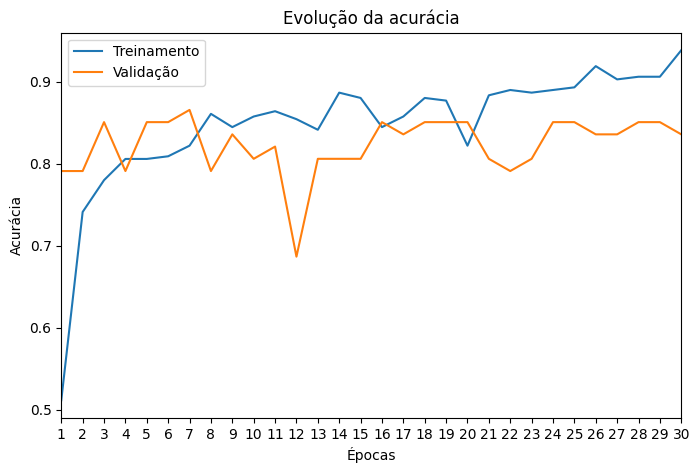

In [320]:
import matplotlib.pyplot as plt

# Avaliação no conjunto de teste
test_loss, test_acc = model.evaluate(test_generator)
print(f"Acurácia de teste: {test_acc:.4f}")

# Curvas de aprendizado
combined_accuracy = history.history['accuracy'] + fine_history.history['accuracy']
combined_val_accuracy = history.history['val_accuracy'] + fine_history.history['val_accuracy']

total_epochs = len(combined_accuracy)
epochs_labels = range(1, total_epochs + 1)

plt.figure(figsize=(8, 5))
plt.plot(epochs_labels, combined_accuracy, label='Treinamento')
plt.plot(epochs_labels, combined_val_accuracy, label='Validação')
plt.xlabel('Épocas')
plt.ylabel('Acurácia')
plt.legend()
plt.title('Evolução da acurácia')

# === A SOLUÇÃO DEFINITIVA ===
# Força o Matplotlib a escrever os números de 1 até o total de épocas
# (Se os números ficarem muito colados por ter muitas épocas, use range(1, total_epochs + 1, 2) para pular de 2 em 2)
plt.xticks(range(1, total_epochs + 1))

# Mantemos o limite para cortar a margem automática da esquerda
plt.xlim(left=1, right=total_epochs)
# ============================

plt.show()

In [321]:
model.summary()

Model: "functional_65"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_74 (InputLayer)     │ (None, 320, 320, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_224            │ (None, 10, 10, 1280)   │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_8      │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_22 (Dropout)            │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_22 (Dense)                │ (None, 128)            │       163,968 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_23 (Dropout)            │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_23 (Dense)                │ (None, 4)              │           516 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 6,614,990 (25.23 MB)

 Trainable params: 2,096,260 (8.00 MB)

 Non-trainable params: 326,208 (1.24 MB)

 Optimizer params: 4,192,522 (15.99 MB)

# - 13. Métricas do Modelo

In [322]:
from sklearn.metrics import confusion_matrix, classification_report
import numpy as np

# Obter as previsões do modelo no conjunto de teste
y_pred_probs = model.predict(test_generator)
y_pred = np.argmax(y_pred_probs, axis=1)

# Obter os rótulos verdadeiros do conjunto de teste
y_true = test_generator.classes

# Obter os nomes das classes
class_names = list(test_generator.class_indices.keys())

# Gerar a Matriz de Confusão
cm = confusion_matrix(y_true, y_pred)
print("\nMatriz de Confusão:")
print(cm)

# Gerar o Relatório de Classificação
report = classification_report(y_true, y_pred, target_names=class_names)
print("\nRelatório de Classificação:")
print(report)

5/5 ━━━━━━━━━━━━━━━━━━━━ 8s 1s/step

Matriz de Confusão:
[[ 3  1  0  0]
 [ 0 27  0  1]
 [ 0  0 15  0]
 [ 0  7  0 14]]

Relatório de Classificação:
              precision    recall  f1-score   support

  background       1.00      0.75      0.86         4
    diabetic       0.77      0.96      0.86        28
      normal       1.00      1.00      1.00        15
    pressure       0.93      0.67      0.78        21

    accuracy                           0.87        68
   macro avg       0.93      0.85      0.87        68
weighted avg       0.89      0.87      0.86        68



## Visualização da Matriz de Confusão

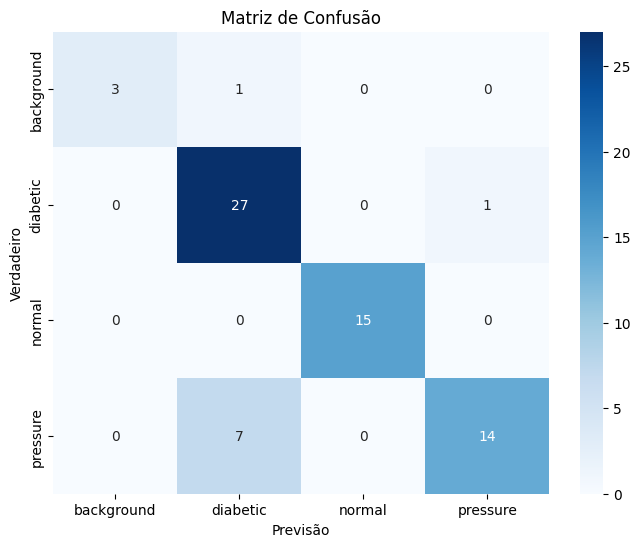

In [323]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=class_names, yticklabels=class_names)
plt.xlabel('Previsão')
plt.ylabel('Verdadeiro')
plt.title('Matriz de Confusão')
plt.show()

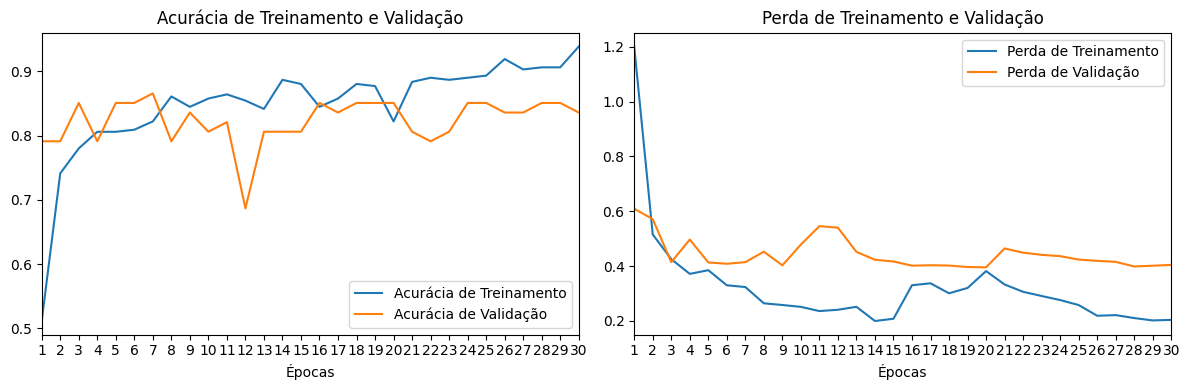

In [324]:
import matplotlib.pyplot as plt

# Concatenar os históricos de treinamento
# Para acurácia
acc = history.history['accuracy'] + fine_history.history['accuracy']
val_acc = history.history['val_accuracy'] + fine_history.history['val_accuracy']

# Para perda
loss = history.history['loss'] + fine_history.history['loss']
val_loss = history.history['val_loss'] + fine_history.history['val_loss']

# Salva o total de épocas para usar nos limites
total_epochs = len(acc)
epochs_range = range(1, total_epochs + 1)

plt.figure(figsize=(12, 4))

# ====================
# Plotar Acurácia
# ====================
plt.subplot(1, 2, 1)
plt.plot(epochs_range, acc, label='Acurácia de Treinamento')
plt.plot(epochs_range, val_acc, label='Acurácia de Validação')
plt.legend(loc='lower right')
plt.title('Acurácia de Treinamento e Validação')
plt.xlabel('Épocas') # Opcional, mas ajuda na leitura

# Aplica a correção do eixo X para o gráfico 1
plt.xticks(epochs_range)
plt.xlim(left=1, right=total_epochs)

# ====================
# Plotar Perda
# ====================
plt.subplot(1, 2, 2)
plt.plot(epochs_range, loss, label='Perda de Treinamento')
plt.plot(epochs_range, val_loss, label='Perda de Validação')
plt.legend(loc='upper right')
plt.title('Perda de Treinamento e Validação')
plt.xlabel('Épocas') # Opcional, mas ajuda na leitura

# Aplica a correção do eixo X para o gráfico 2
plt.xticks(epochs_range)
plt.xlim(left=1, right=total_epochs)

# plt.tight_layout() ajusta os espaçamentos para os gráficos não ficarem colados
plt.tight_layout()
plt.show()

In [325]:
#Quero Gerar a curva AUC e ROC

/tmp/ipykernel_44406/1892738371.py:23: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  colors = plt.cm.get_cmap('tab10', n_classes) # Get distinct colors for each class


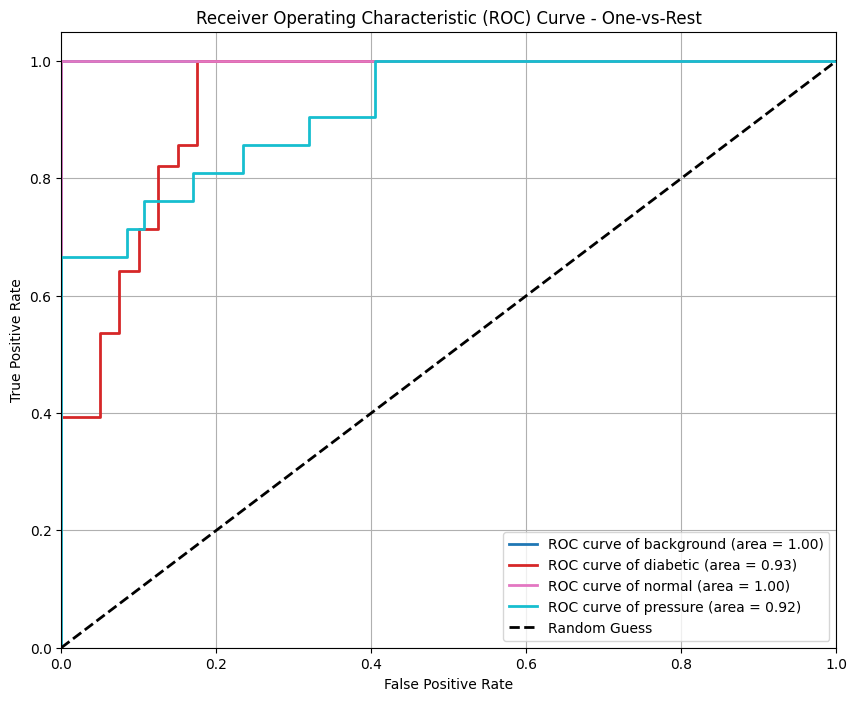

AUC Scores per class:
  background: 1.0000
  diabetic: 0.9339
  normal: 1.0000
  pressure: 0.9179


In [326]:
from sklearn.metrics import roc_curve, auc
from sklearn.preprocessing import label_binarize
import matplotlib.pyplot as plt
import numpy as np

# Assuming y_true and y_pred_probs (from previous cells) are available

# Binarize the true labels for one-vs-rest ROC
# class_names was obtained from test_generator.class_indices.keys()
n_classes = len(class_names)
y_true_binarized = label_binarize(y_true, classes=np.arange(n_classes))

# Compute ROC curve and ROC area for each class
fpr = dict()
tpr = dict()
roc_auc = dict()
for i in range(n_classes):
    fpr[i], tpr[i], _ = roc_curve(y_true_binarized[:, i], y_pred_probs[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])

# Plot all ROC curves
plt.figure(figsize=(10, 8))
colors = plt.cm.get_cmap('tab10', n_classes) # Get distinct colors for each class

for i, class_name in enumerate(class_names):
    plt.plot(fpr[i], tpr[i], color=colors(i), lw=2,
             label=f'ROC curve of {class_name} (area = {roc_auc[i]:.2f})')

plt.plot([0, 1], [0, 1], 'k--', lw=2, label='Random Guess')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve - One-vs-Rest')
plt.legend(loc="lower right")
plt.grid(True)
plt.show()

print("AUC Scores per class:")
for i, class_name in enumerate(class_names):
    print(f"  {class_name}: {roc_auc[i]:.4f}")

# - 14. Salvar o Modelo

In [327]:
# model.save('/content/drive/MyDrive/mobilenetv2_wounds_model_4class.h5')

# - 15. Salvar o Modelo em TFLite / Excel

In [328]:
# import tensorflow as tf
# import pandas as pd
# import os

# # Instalar xlsxwriter se não estiver presente
# try:
#     import xlsxwriter
# except ImportError:
#     %pip install xlsxwriter
#     import xlsxwriter

# # Caminho para salvar o modelo TFLite
# tflite_model_path = '/content/drive/MyDrive/mobilenetv2_wounds_model_4class.tflite'

# # Converter o modelo Keras para TensorFlow Lite
# converter = tf.lite.TFLiteConverter.from_keras_model(model)
# tflite_model = converter.convert()

# # Salvar o modelo TFLite
# with open(tflite_model_path, 'wb') as f:
#     f.write(tflite_model)

# print(f"Modelo salvo em TFLite: {tflite_model_path}")

# # --- Salvar resultados em Excel ---

# # Caminho para o arquivo Excel
# excel_output_path = '/content/drive/MyDrive/resultados_classificacao_mobilenetv2_4class.xlsx'

# # Matriz de Confusão para DataFrame
# cm_df = pd.DataFrame(cm, index=class_names, columns=class_names)

# # Relatório de Classificação para DataFrame
# # Splitting the report string into lines and then processing it
# report_data = []
# lines = report.split('\n')
# # Skip first line (empty), second line (header), and last three lines (accuracy, macro avg, weighted avg)
# for line in lines[2:-5]:
#     if line.strip():
#         parts = line.split()
#         class_name = parts[0]
#         precision = float(parts[1])
#         recall = float(parts[2])
#         f1_score = float(parts[3])
#         support = int(parts[4])
#         report_data.append([class_name, precision, recall, f1_score, support])

# report_df = pd.DataFrame(report_data, columns=['Class', 'Precision', 'Recall', 'F1-Score', 'Support'])

# # Para as linhas de 'accuracy', 'macro avg' e 'weighted avg'
# summary_data = []
# for line in lines[-4:]:
#     if line.strip() and not line.startswith('accuracy'): # Skip accuracy line as it's computed differently sometimes
#         parts = line.split()
#         if parts[0] == 'accuracy': # Special handling for accuracy line if it appears before macro avg
#             value = float(parts[1])
#             summary_data.append(['accuracy', value, '', '', int(parts[2])])
#         else:
#             metric_type = ' '.join(parts[:-4]) # 'macro avg' or 'weighted avg'
#             precision = float(parts[-4])
#             recall = float(parts[-3])
#             f1_score = float(parts[-2])
#             support = int(parts[-1])
#             summary_data.append([metric_type, precision, recall, f1_score, support])

# summary_df = pd.DataFrame(summary_data, columns=['Class', 'Precision', 'Recall', 'F1-Score', 'Support'])

# # Salvar em um arquivo Excel com múltiplas abas
# with pd.ExcelWriter(excel_output_path, engine='xlsxwriter') as writer:
#     cm_df.to_excel(writer, sheet_name='Confusion Matrix')
#     report_df.to_excel(writer, sheet_name='Classification Report', index=False)
#     summary_df.to_excel(writer, sheet_name='Summary Metrics', index=False)

# print(f"Resultados da classificação salvos em Excel: {excel_output_path}")

# - 16 .  Avaliação Manual

In [329]:

# import pandas as pd

# # 1. Extrair os caminhos dos arquivos e os rótulos
# # O test_generator guarda os caminhos em .filenames
# caminhos = test_generator.filenames
# # Você já tem y_true e y_pred calculados na célula anterior

# # 2. Criar o DataFrame com os resultados
# df_resultados = pd.DataFrame({
#     'arquivo': caminhos,
#     'real': y_true,
#     'predito': y_pred
# })

# # 3. Mapear os números para os nomes das classes (usando o class_names que você já definiu)
# mapeamento = {i: nome for i, nome in enumerate(class_names)}
# df_resultados['real'] = df_resultados['real'].map(mapeamento)
# df_resultados['predito'] = df_resultados['predito'].map(mapeamento)

# # 4. Filtrar apenas onde o modelo errou
# df_erros = df_resultados[df_resultados['real'] != df_resultados['predito']].copy()

# # 5. Adicionar a coluna para sua análise visual
# df_erros['perfil_visual'] = "" # Você vai preencher isso no Excel/Sheets

# # 6. Salvar no Google Drive
# caminho_csv = '/content/drive/MyDrive/HealScan_Analise_Errosws_Mobile.csv'
# df_erros.to_csv(caminho_csv, index=False)

# print(f"✅ Sucesso! Arquivo gerado com {len(df_erros)} erros.")
# print(f"📂 Local: {caminho_csv}")


🔍 Foram encontrados 9 erros. Gerando visualização...


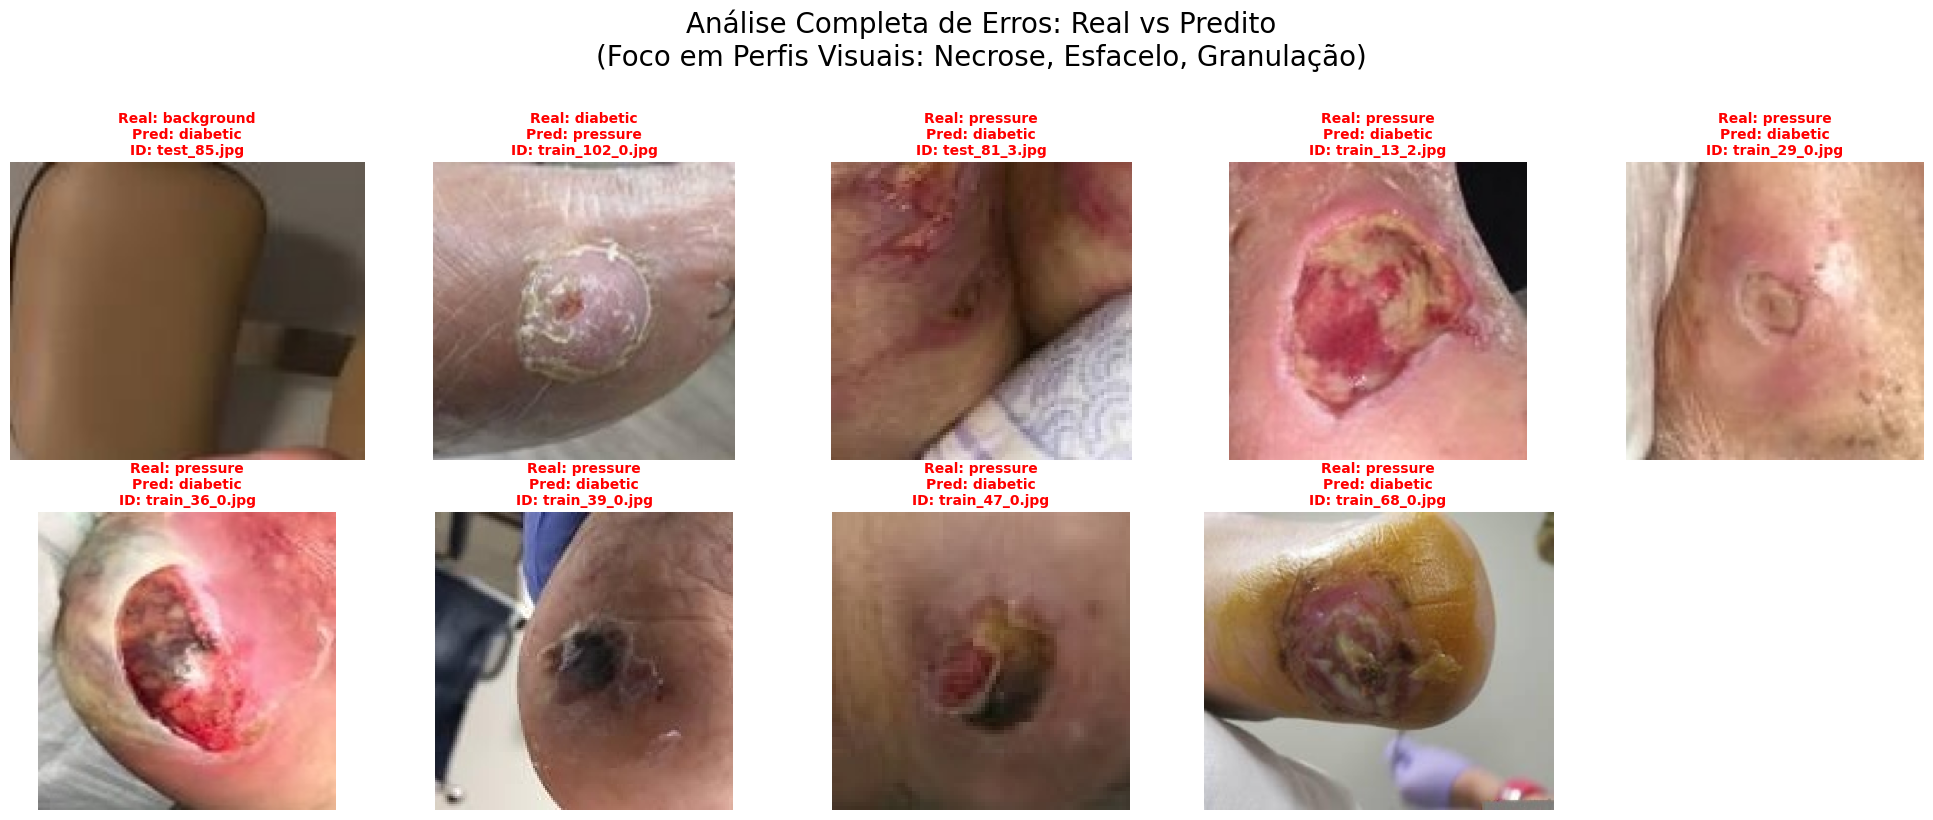

In [330]:
import matplotlib.pyplot as plt
import numpy as np
import math

# 1. Identificar todos os índices de erro
erros_indices = np.where(y_pred != y_true)[0]
total_erros = len(erros_indices)

if total_erros == 0:
    print("✅ O modelo não cometeu erros no conjunto de teste!")
else:
    print(f"🔍 Foram encontrados {total_erros} erros. Gerando visualização...")

    # Configuração da grade (grid) de visualização
    # Vamos exibir 5 imagens por linha
    cols = 5
    rows = math.ceil(total_erros / cols)

    plt.figure(figsize=(20, 4 * rows))
    plt.suptitle("Análise Completa de Erros: Real vs Predito\n(Foco em Perfis Visuais: Necrose, Esfacelo, Granulação)",
                 fontsize=20, y=1.02)

    filepaths = test_generator.filepaths

    for i, idx in enumerate(erros_indices):
        plt.subplot(rows, cols, i + 1)

        # Carregar imagem
        img_path = filepaths[idx]
        img = plt.imread(img_path)
        plt.imshow(img)

        # Rótulos
        true_label = class_names[y_true[idx]]
        pred_label = class_names[y_pred[idx]]

        # Título com as informações do erro
        # Pegamos o nome do arquivo para facilitar se você precisar buscar no Drive
        nome_arquivo = img_path.split('/')[-1]

        plt.title(f"Real: {true_label}\nPred: {pred_label}\nID: {nome_arquivo}",
                  color="red", fontsize=10, fontweight='bold')
        plt.axis("off")

    plt.tight_layout()
    # Salva em alta resolução para você poder dar zoom e analisar cada uma
    plt.savefig("galeria_completa_erros.png", bbox_inches='tight', dpi=150)
    plt.show()

Encontrados 9 erros para análise Grad-CAM.
1/1 ━━━━━━━━━━━━━━━━━━━━ 5s 5s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 226ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 123ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 160ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 225ms/step


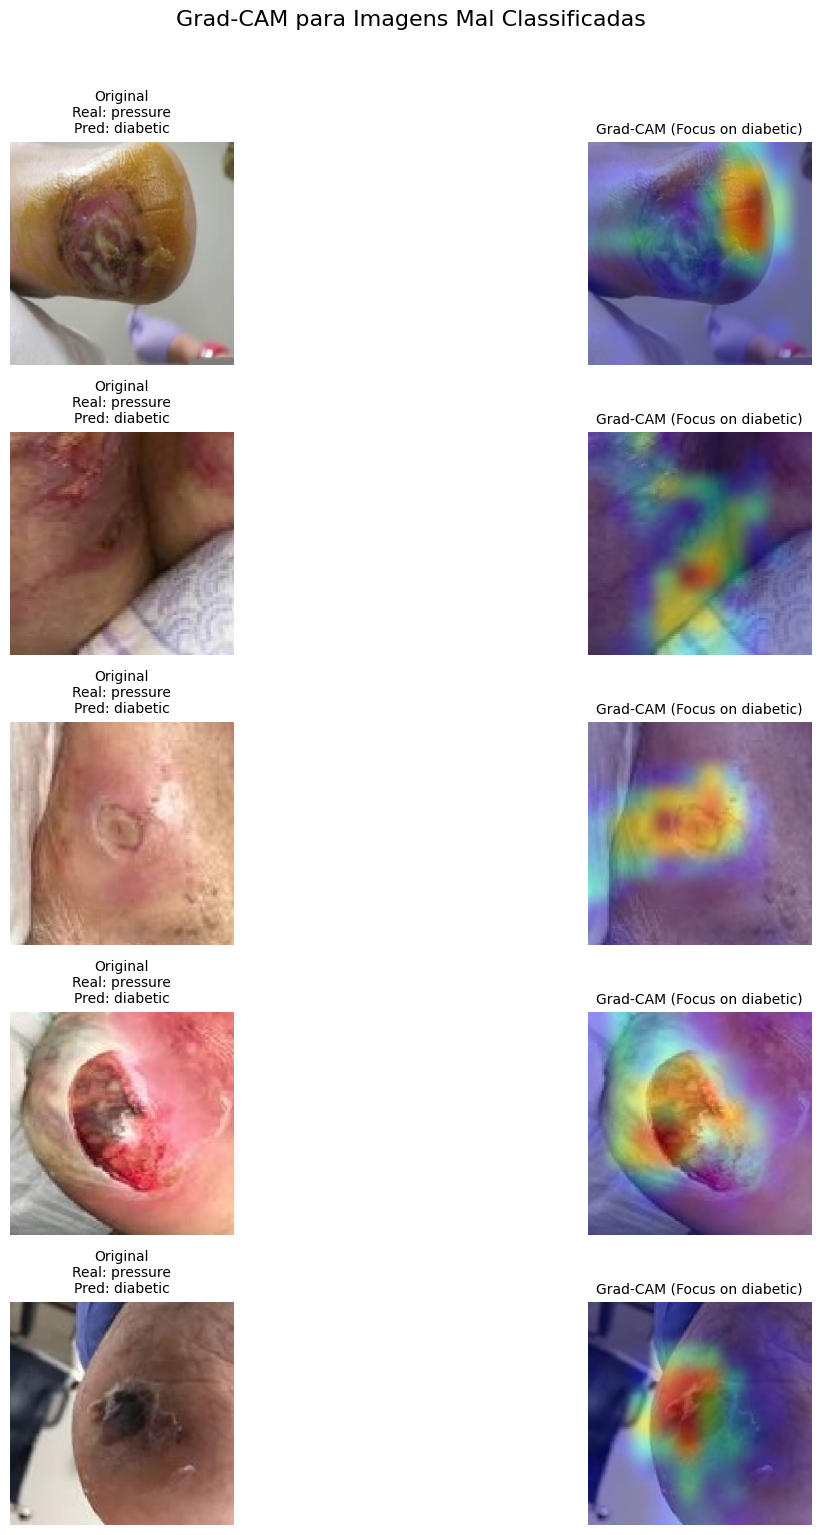

In [333]:
import matplotlib.cm as cm
import matplotlib.pyplot as plt
import numpy as np
import tensorflow as tf
import os
import pandas as pd # Import pandas
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input # Import for preprocessing

def make_gradcam_heatmap(img_array, model, last_conv_layer_name, pred_index=None):
    # Ensure img_array has a batch dimension if it's just (H, W, C)
    if len(img_array.shape) == 3:
        img_array = np.expand_dims(img_array, axis=0)

    # 1. Define a new input for the Grad-CAM model
    # Use img_array.shape[1:] to get (H, W, C) without the batch dimension
    grad_cam_inputs = tf.keras.Input(shape=img_array.shape[1:])

    # 2. Get the base MobileNetV2 layer from the main model
    base_model_layer = model.get_layer('mobilenetv2_1.00_224')

    # 3. Pass the new input through the base model layer (feature extractor)
    # The output of MobileNetV2 with include_top=False is its last conv layer features.
    # Pass training=False to ensure inference mode (e.g., BatchNorm layers behave correctly)
    features_from_base = base_model_layer(grad_cam_inputs, training=False)

    # 4. Reconstruct the classification head of the original model
    # Iterate through the layers of the original model's head (after the base_model_layer)
    # The main 'model' structure is: InputLayer -> mobilenetv2_1.00_224 -> GlobalAveragePooling2D -> Dropout -> Dense -> Dropout -> Dense
    # So, we need to apply layers starting from GlobalAveragePooling2D
    x_head = features_from_base

    # We start from model.layers[2] because index 0 is InputLayer and index 1 is mobilenetv2_1.00_224
    for layer in model.layers[2:]:
        # Apply the layer to x_head, handling Dropout layers in inference mode
        if isinstance(layer, tf.keras.layers.Dropout):
            x_head = layer(x_head, training=False) # Ensure dropout is off for inference
        else:
            x_head = layer(x_head)

    final_preds_from_head = x_head # This is the final prediction tensor

    # 5. Create the Grad-CAM model with the new input and both desired outputs
    grad_model = tf.keras.models.Model(
        inputs=grad_cam_inputs,
        outputs=[features_from_base, final_preds_from_head]
    )

    with tf.GradientTape() as tape:
        # Watch the input tensor for gradients
        img_tensor = tf.cast(img_array, tf.float32)
        tape.watch(img_tensor)

        # Call grad_model with the image tensor.
        # Since grad_cam_inputs was a single Input, passing img_tensor directly is correct.
        last_conv_layer_output, preds = grad_model(img_tensor)

        if pred_index is None:
            # Get the index of the predicted class with highest probability
            pred_index = tf.argmax(preds[0])
        class_channel = preds[:, pred_index]

    # Compute gradients of the predicted class with respect to the last conv layer output
    grads = tape.gradient(class_channel, last_conv_layer_output)

    # Pool the gradients over all the spatial dimensions
    pooled_grads = tf.reduce_mean(grads, axis=(0, 1, 2))

    last_conv_layer_output = last_conv_layer_output[0] # Remove batch dimension
    heatmap = last_conv_layer_output @ pooled_grads[..., tf.newaxis]
    heatmap = tf.squeeze(heatmap)

    # Normalize the heatmap to be between 0 and 1
    heatmap = tf.maximum(heatmap, 0) / tf.math.reduce_max(heatmap)
    return heatmap.numpy()

def display_gradcam(img_path, heatmap, alpha=0.4):
    # Load the original image again for display (without MobileNetV2 preprocessing)
    # The image from file is expected to be [0, 255]
    img = tf.keras.preprocessing.image.load_img(img_path, target_size=(320, 320)) # Changed target_size to 320
    img = tf.keras.preprocessing.image.img_to_array(img)

    # Rescale heatmap to a range 0-255
    heatmap = np.uint8(255 * heatmap)

    # Use jet colormap to colorize heatmap
    jet = plt.colormaps["jet"] # Use plt.colormaps instead of cm.get_cmap

    # Use RGB values of the colormap
    jet_colors = jet(np.arange(256))[:, :3]
    jet_heatmap = jet_colors[heatmap]

    # Create an image with RGB colorized heatmap
    jet_heatmap = tf.keras.preprocessing.image.array_to_img(jet_heatmap)
    jet_heatmap = jet_heatmap.resize((img.shape[1], img.shape[0]))
    jet_heatmap = tf.keras.preprocessing.image.img_to_array(jet_heatmap)

    # Superimpose the heatmap on original image
    # Convert original image to float for blending
    img_float = img.astype(np.float32)
    superimposed_img = jet_heatmap * alpha + img_float * (1 - alpha)

    # Normalize to 0-255 and convert back to image
    superimposed_img = np.clip(superimposed_img, 0, 255).astype(np.uint8)
    # Return as numpy array directly, not an Image object
    return superimposed_img

# Define the preprocessing function
combined_preprocessing_function = preprocess_input

# --- Main execution part to pick random error images and display Grad-CAM ---

# 1. Extract file paths and labels
caminhos = test_generator.filenames

# 2. Create DataFrame with results
df_resultados = pd.DataFrame({
    'arquivo': caminhos,
    'real': y_true,
    'predito': y_pred
})

# 3. Map numerical labels to class names
mapeamento = {i: nome for i, nome in enumerate(class_names)}
df_resultados['real'] = df_resultados['real'].map(mapeamento)
df_resultados['predito'] = df_resultados['predito'].map(mapeamento)

# 4. Filter for misclassified images
df_erros = df_resultados[df_resultados['real'] != df_resultados['predito']].copy()

# Assuming 'df_erros', 'test_generator', 'model', 'class_names' are available from previous cells.
# And 'combined_preprocessing_function' (from cell voGjGoPVIiT2) is available.

if 'df_erros' in locals() and not df_erros.empty:
    print(f"Encontrados {len(df_erros)} erros para análise Grad-CAM.")
    # Take a random sample of misclassified images, e.g., 5 images
    num_samples_to_show = min(5, len(df_erros)) # Show up to 5 misclassified images
    sample_erros = df_erros.sample(num_samples_to_show)

    plt.figure(figsize=(15, num_samples_to_show * 3))
    plt.suptitle("Grad-CAM para Imagens Mal Classificadas", fontsize=16, y=1.02)

    for i, (idx, row) in enumerate(sample_erros.iterrows()):
        relative_img_path = row['arquivo'] # e.g., 'diabetic/129_0.jpg'

        # Need to reconstruct the full path from the test_generator directory
        test_dir_base = "/content/drive/MyDrive/dataset_master_split/test"
        full_img_path = os.path.join(test_dir_base, relative_img_path)

        # Load and preprocess the image for the model
        img_raw = tf.keras.preprocessing.image.load_img(full_img_path, target_size=(320, 320)) # Resolução
        img_array = tf.keras.preprocessing.image.img_to_array(img_raw)

        # Apply the same preprocessing function used for training/inference
        # This function also includes grayscale conversion and MobileNetV2 preprocessing
        img_preprocessed = combined_preprocessing_function(img_array)

        # Get predicted class (the one the model actually predicted)
        # model.predict expects a batch, so add the batch dimension for prediction
        predictions = model.predict(np.expand_dims(img_preprocessed, axis=0))
        predicted_class_idx = np.argmax(predictions[0])
        predicted_class_name = class_names[predicted_class_idx]

        # Get actual class name
        true_class_name = row['real']

        # Generate Grad-CAM heatmap
        # 'out_relu' is the last convolutional layer in MobileNetV2 base
        # pred_index is passed to focus the heatmap on the class the model predicted (correctly or incorrectly)
        heatmap = make_gradcam_heatmap(img_preprocessed, model, 'out_relu', pred_index=predicted_class_idx)

        # Display results
        plt.subplot(num_samples_to_show, 2, i * 2 + 1)
        plt.imshow(img_raw) # Show original image
        plt.title(f"Original\nReal: {true_class_name}\nPred: {predicted_class_name}", fontsize=10)
        plt.axis("off")

        plt.subplot(num_samples_to_show, 2, i * 2 + 2)
        # Use the numpy array returned by display_gradcam directly
        superimposed_img_np = display_gradcam(full_img_path, heatmap)
        plt.imshow(superimposed_img_np)
        plt.title(f"Grad-CAM (Focus on {predicted_class_name})", fontsize=10)
        plt.axis("off")
    plt.tight_layout()
    plt.show()
else:
    print("Não foi possível carregar 'df_erros' ou o DataFrame está vazio. Verifique se a célula de análise de erros foi executada e se há erros.")

Encontrados 59 acertos para análise Grad-CAM.
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 406ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 353ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 204ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 203ms/step


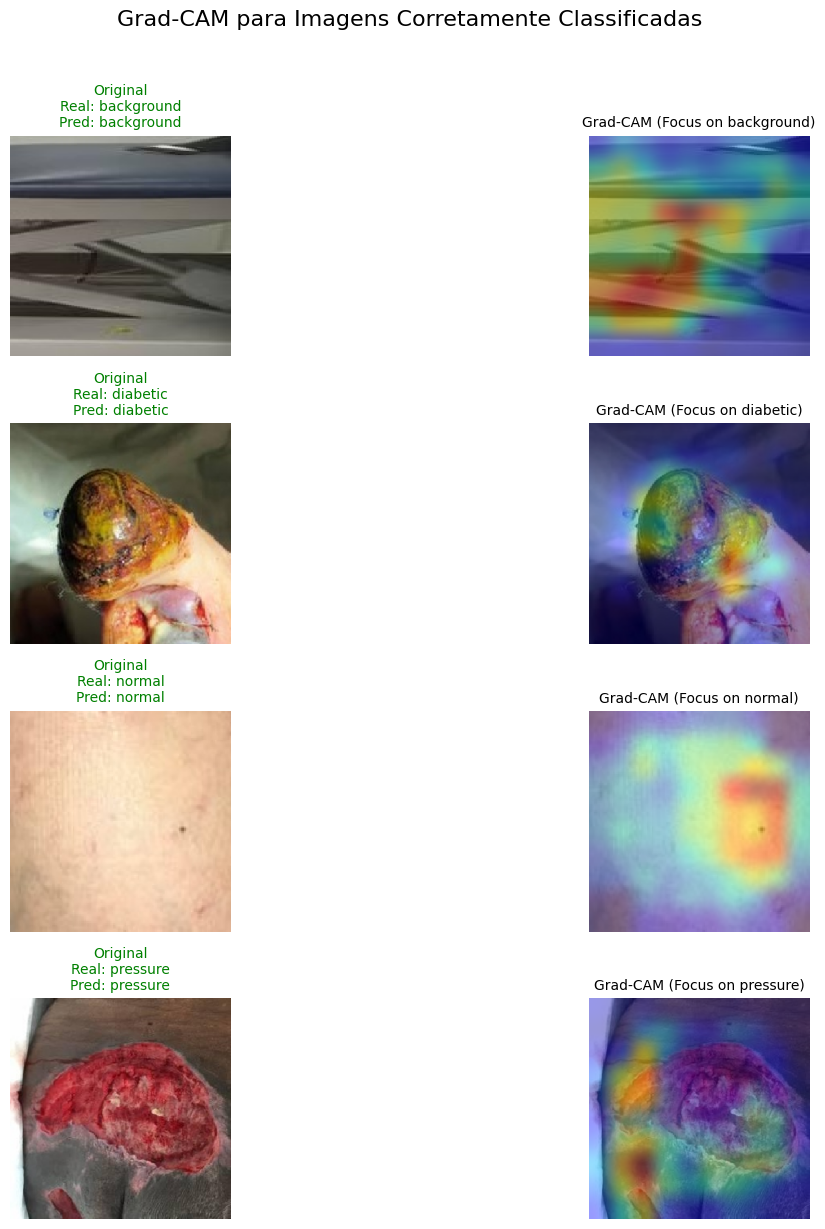

In [335]:
import matplotlib.cm as cm
import matplotlib.pyplot as plt
import numpy as np
import os
import pandas as pd
import tensorflow as tf
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input # Import for preprocessing

def make_gradcam_heatmap(img_array, model, last_conv_layer_name, pred_index=None):
    # Ensure img_array has a batch dimension if it's just (H, W, C)
    if len(img_array.shape) == 3:
        img_array = np.expand_dims(img_array, axis=0)

    # 1. Define a new input for the Grad-CAM model
    # Use img_array.shape[1:] to get (H, W, C) without the batch dimension
    grad_cam_inputs = tf.keras.Input(shape=img_array.shape[1:])

    # 2. Get the base MobileNetV2 layer from the main model
    base_model_layer = model.get_layer('mobilenetv2_1.00_224')

    # 3. Pass the new input through the base model layer (feature extractor)
    # The output of MobileNetV2 with include_top=False is its last conv layer features.
    # Pass training=False to ensure inference mode (e.g., BatchNorm layers behave correctly)
    features_from_base = base_model_layer(grad_cam_inputs, training=False)

    # 4. Reconstruct the classification head of the original model
    # Iterate through the layers of the original model's head (after the base_model_layer)
    # The main 'model' structure is: InputLayer -> mobilenetv2_1.00_224 -> GlobalAveragePooling2D -> Dropout -> Dense -> Dropout -> Dense
    # So, we need to apply layers starting from GlobalAveragePooling2D
    x_head = features_from_base

    # We start from model.layers[2] because index 0 is InputLayer and index 1 is mobilenetv2_1.00_224
    for layer in model.layers[2:]:
        # Apply the layer to x_head, handling Dropout layers in inference mode
        if isinstance(layer, tf.keras.layers.Dropout):
            x_head = layer(x_head, training=False) # Ensure dropout is off for inference
        else:
            x_head = layer(x_head)

    final_preds_from_head = x_head # This is the final prediction tensor

    # 5. Create the Grad-CAM model with the new input and both desired outputs
    grad_model = tf.keras.models.Model(
        inputs=grad_cam_inputs,
        outputs=[features_from_base, final_preds_from_head]
    )

    with tf.GradientTape() as tape:
        # Watch the input tensor for gradients
        img_tensor = tf.cast(img_array, tf.float32)
        tape.watch(img_tensor)

        # Call grad_model with the image tensor.
        # Since grad_cam_inputs was a single Input, passing img_tensor directly is correct.
        last_conv_layer_output, preds = grad_model(img_tensor)

        if pred_index is None:
            # Get the index of the predicted class with highest probability
            pred_index = tf.argmax(preds[0])
        class_channel = preds[:, pred_index]

    # Compute gradients of the predicted class with respect to the last conv layer output
    grads = tape.gradient(class_channel, last_conv_layer_output)

    # Pool the gradients over all the spatial dimensions
    pooled_grads = tf.reduce_mean(grads, axis=(0, 1, 2))

    last_conv_layer_output = last_conv_layer_output[0] # Remove batch dimension
    heatmap = last_conv_layer_output @ pooled_grads[..., tf.newaxis]
    heatmap = tf.squeeze(heatmap)

    # Normalize the heatmap to be between 0 and 1
    heatmap = tf.maximum(heatmap, 0) / tf.math.reduce_max(heatmap)
    return heatmap.numpy()

def display_gradcam(img_path, heatmap, alpha=0.4):
    # Load the original image again for display (without MobileNetV2 preprocessing)
    # The image from file is expected to be [0, 255]
    img = tf.keras.preprocessing.image.load_img(img_path, target_size=(320, 320)) # Alterei aqui a resolução
    img = tf.keras.preprocessing.image.img_to_array(img)

    # Rescale heatmap to a range 0-255
    heatmap = np.uint8(255 * heatmap)

    # Use jet colormap to colorize heatmap
    jet = plt.colormaps["jet"] # Use plt.colormaps instead of cm.get_cmap

    # Use RGB values of the colormap
    jet_colors = jet(np.arange(256))[:, :3]
    jet_heatmap = jet_colors[heatmap]

    # Create an image with RGB colorized heatmap
    jet_heatmap = tf.keras.preprocessing.image.array_to_img(jet_heatmap)
    jet_heatmap = jet_heatmap.resize((img.shape[1], img.shape[0]))
    jet_heatmap = tf.keras.preprocessing.image.img_to_array(jet_heatmap)

    # Superimpose the heatmap on original image
    # Convert original image to float for blending
    img_float = img.astype(np.float32)
    superimposed_img = jet_heatmap * alpha + img_float * (1 - alpha)

    # Normalize to 0-255 and convert back to image
    superimposed_img = np.clip(superimposed_img, 0, 255).astype(np.uint8)
    # Return as numpy array directly, not an Image object
    return superimposed_img

# Define the preprocessing function
combined_preprocessing_function = preprocess_input

# Re-create df_resultados for robustness if this cell is run independently
caminhos = test_generator.filenames
df_resultados = pd.DataFrame({
    'arquivo': caminhos,
    'real': y_true,
    'predito': y_pred
})
mapeamento = {i: nome for i, nome in enumerate(class_names)}
df_resultados['real'] = df_resultados['real'].map(mapeamento)
df_resultados['predito'] = df_resultados['predito'].map(mapeamento)

# 1. Filter for correctly classified images
df_acertos = df_resultados[df_resultados['real'] == df_resultados['predito']].copy()

if not df_acertos.empty:
    print(f"Encontrados {len(df_acertos)} acertos para análise Grad-CAM.")

    # Collect one correctly classified image per class
    sample_acertos_list = []
    for class_name_str in class_names:
        class_hits = df_acertos[df_acertos['real'] == class_name_str]
        if not class_hits.empty:
            sample_acertos_list.append(class_hits.sample(1))

    if not sample_acertos_list:
        print("Nenhuma imagem corretamente classificada encontrada para exibir Grad-CAM.")
    else:
        sample_acertos = pd.concat(sample_acertos_list)
        num_samples_to_show = len(sample_acertos)

        plt.figure(figsize=(15, num_samples_to_show * 3))
        plt.suptitle("Grad-CAM para Imagens Corretamente Classificadas", fontsize=16, y=1.02)

        for i, (idx, row) in enumerate(sample_acertos.iterrows()):
            relative_img_path = row['arquivo'] # e.g., 'diabetic/129_0.jpg'

            # Need to reconstruct the full path from the test_generator directory
            test_dir_base = "/content/drive/MyDrive/dataset_master_split/test"
            full_img_path = os.path.join(test_dir_base, relative_img_path)

            # Load and preprocess the image for the model
            img_raw = tf.keras.preprocessing.image.load_img(full_img_path, target_size=(320, 320)) #alterei ak
            img_array = tf.keras.preprocessing.image.img_to_array(img_raw)

            # Apply the same preprocessing function used for training/inference
            img_preprocessed = combined_preprocessing_function(img_array)

            # Get predicted class (the one the model actually predicted)
            predictions = model.predict(np.expand_dims(img_preprocessed, axis=0))
            predicted_class_idx = np.argmax(predictions[0])
            predicted_class_name = class_names[predicted_class_idx]

            # Get actual class name (should be the same as predicted for correct ones)
            true_class_name = row['real']

            # Generate Grad-CAM heatmap
            heatmap = make_gradcam_heatmap(img_preprocessed, model, 'out_relu', pred_index=predicted_class_idx)

            # Display results
            plt.subplot(num_samples_to_show, 2, i * 2 + 1)
            plt.imshow(img_raw) # Show original image
            plt.title(f"Original\nReal: {true_class_name}\nPred: {predicted_class_name}", fontsize=10, color="green")
            plt.axis("off")

            plt.subplot(num_samples_to_show, 2, i * 2 + 2)
            superimposed_img_np = display_gradcam(full_img_path, heatmap)
            plt.imshow(superimposed_img_np)
            plt.title(f"Grad-CAM (Focus on {predicted_class_name})", fontsize=10)
            plt.axis("off")
        plt.tight_layout()
        plt.show()
else:
    print("Não foi possível carregar 'df_acertos' ou o DataFrame está vazio. Verifique se a célula de análise de resultados foi executada e se há acertos.")